# Stage 0: Excitatory Scaffold
## Ascoli Framework — Zero-Order Information Flow
**Hippocampal Connectome Analysis | Ascoli Lab, GMU**

This notebook implements Stage 0 of the multi-stage information-flow analysis pipeline applied to a 72-node hippocampal connectome derived from Hippocampome.org.

**Scope:**
- EDA: all 72 neuron types — full signed weight matrix characterization
- Build 27-node excitatory-only subnetwork; verify single strongly connected component
- Hub rankings: out-strength, in-strength, overall (E→E subgraph)
- PageRank & Markov stationary distribution on E→E subgraph
- Greedy path tracing: Variant A (stop), Variant B (skip loops), Variant C (edge exhaustion)
- Terminus diagnosis: why each path stopped, what the would-go-to node was
- Short excitatory cycle enumeration: lengths 2–4, hierarchical labels
- Region-level flow heatmap + trisynaptic circuit visualization
- Signed weight matrix heatmaps (72×72 and 27×27)
- Greedy edge cover: minimum tours to traverse all 268 E→E edges

**Conventions:**
- `w_ij[i,j]` = weight of synapse from row i (pre) to column j (post)
- 'Stages' not 'layers' (per Dr. Ascoli's convention)
- MEC naming patch applied at load time (see Section 1)

## 0. Imports & Configuration

All imports, paths, constants, and helper functions are consolidated here.

**Environment support:**
- **Google Colab (primary):** Mounts Drive automatically. Data files should be in `MyDrive/Ascoli_LabRotation/`. Package installs are handled in this cell.
- **Local Jupyter (for PI/offline use):** No Drive mount, no pip installs. Expects data files in the same relative folder structure alongside this notebook (`matrices/`, `outputs/`). All standard packages (pandas, numpy, networkx, matplotlib) must be installed in the local environment.

The cell prints a file check so you can immediately see if paths are resolving correctly before running anything downstream.

## 0. Imports & Configuration

All imports, paths, constants, and helper functions are consolidated here. Edit paths at the top if running locally vs. Colab.

In [1]:
import sys
import os
import warnings
from collections import defaultdict

# ── Environment detection & setup ─────────────────────────────────────────────
# This notebook runs in two environments:
#   - Google Colab (primary working environment): mounts Drive, installs packages
#   - Local Jupyter (for PI / offline use): expects packages already installed,
#     data files in the same folder structure relative to this notebook
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Ascoli_LabRotation/'

    # Install any packages not in the Colab base image
    import subprocess
    pkgs = ['networkx'  # already in Colab but pin here for explicitness
    ]
    # networkx, numpy, pandas, matplotlib are all pre-installed in Colab;
    # add any extras here if needed in future stages (e.g. igraph, nctpy)
    print('Colab environment detected. Drive mounted.')
else:
    # Local execution: data files should be in the same relative structure
    # alongside this notebook (i.e. matrices/ and outputs/ folders at same level)
    BASE = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else ''
    # Fallback: if running interactively without __file__, BASE = '' uses CWD
    print(f'Local environment detected. BASE = "{BASE}" (CWD = {os.getcwd()})')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
warnings.filterwarnings('ignore')

# ── File paths ────────────────────────────────────────────────────────────────
# Expected directory layout (same for Colab Drive and local download):
#   Ascoli_LabRotation/
#     matrices/
#       w_ij_gaa.csv
#       izhikevich_72_v3.csv
#     outputs/
#       scaffolds/       <- created automatically
#     stage0_excitatory_scaffold_CLEAN.ipynb   <- this file
WEIGHT_MATRIX = os.path.join(BASE, 'matrices', 'w_ij_gaa.csv')
NEURON_PARAMS = os.path.join(BASE, 'matrices', 'izhikevich_72_v3.csv')
TABLE_DIR     = os.path.join(BASE, 'outputs', 'scaffolds', '')
os.makedirs(TABLE_DIR, exist_ok=True)

# Quick file check
for label, path in [('Weight matrix', WEIGHT_MATRIX), ('Neuron params', NEURON_PARAMS)]:
    status = '✓' if os.path.exists(path) else '✗ NOT FOUND'
    print(f'  {label}: {status}  ({path})')

# ── Region color convention (canonical for all stages) ───────────────────────
region_colors = {
    'DG':    '#E67E22',
    'CA3':   '#2ECC71',
    'CA2':   '#1ABC9C',
    'CA1':   '#3498DB',
    'MEC':   '#9B59B6',
    'LEC':   '#E91E63',
    'EC':    '#95A5A6',
    'Other': '#7F8C8D',
}
region_order_list = ['DG', 'CA3', 'CA2', 'CA1', 'MEC', 'LEC', 'EC', 'Other']

# ── MEC naming patch ──────────────────────────────────────────────────────────
# w_ij_gaa.csv calls one node 'MEC LV Multipolar Pyramidal'; all other files
# call it 'MEC LIII Multipolar Principal'. Must be applied at load time,
# before any node list construction.
MEC_PATCH = {'MEC LV Multipolar Pyramidal': 'MEC LIII Multipolar Principal'}

# ── Helper: region from node name ────────────────────────────────────────────
def region(name):
    for r in ['DG', 'CA3', 'CA2', 'CA1', 'MEC', 'LEC', 'EC']:
        if name.startswith(r):
            return r
    return 'Other'

print(f'\nSetup complete. Output directory: {TABLE_DIR}')


Mounted at /content/drive
Setup complete.
Output directory: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/


## 1. Load Data

Load weight matrix and neuron type file. Apply MEC naming patch immediately after loading, before any node list construction. This ensures consistent node naming across all downstream operations.

In [2]:
W_raw = pd.read_csv(WEIGHT_MATRIX, index_col=0)
ei_df = pd.read_csv(NEURON_PARAMS)

# Apply MEC naming patch to weight matrix index and columns
W_raw.index   = [MEC_PATCH.get(n, n) for n in W_raw.index]
W_raw.columns = [MEC_PATCH.get(n, n) for n in W_raw.columns]
W = W_raw.copy()

w_nodes   = list(W.index)
ei_lookup = dict(zip(ei_df['Neuron Type'], ei_df['E/I']))

# Build node lists — patch must already be applied before this step
excitatory = [n for n in ei_df[ei_df['E/I'] == 'e']['Neuron Type'].tolist() if n in w_nodes]
inhibitory = [n for n in ei_df[ei_df['E/I'] == 'i']['Neuron Type'].tolist() if n in w_nodes]
missing_e  = [n for n in ei_df[ei_df['E/I'] == 'e']['Neuron Type'].tolist() if n not in w_nodes]

print(f'Weight matrix : {W.shape[0]}×{W.shape[1]} neurons')
print(f'Excitatory    : {len(excitatory)} in W')
print(f'Inhibitory    : {len(inhibitory)} in W')
if missing_e:
    print(f'Missing E nodes (in izhikevich file but not in W): {missing_e}')
    print('  -> Expected: MEC LIII Multipolar Principal is missing from w_ij_gaa.csv')

Weight matrix : 72×72 neurons
Excitatory    : 28 in W
Inhibitory    : 44 in W


## 2. EDA: All 72 Neuron Types

Row sums = total outgoing synaptic weight (out-strength). Column sums = total incoming weight (in-strength). Excitatory neurons cluster as net sources (positive row sums); inhibitory neurons cluster as net sinks (negative or near-zero row sums).

In [3]:
eda_rows = []
for node in w_nodes:
    row = W.loc[node]
    col = W[node]
    eda_rows.append({
        'neuron_type': node,
        'E/I':         ei_lookup.get(node, '?'),
        'region':      region(node),
        'row_sum':     row.sum(),
        'row_max':     row.max(),
        'row_min':     row.min(),
        'row_median':  row.median(),
        'col_sum':     col.sum(),
        'col_max':     col.max(),
        'col_min':     col.min(),
        'col_median':  col.median(),
        'n_out':       int((row != 0).sum()),
        'n_in':        int((col != 0).sum()),
    })

eda_df = pd.DataFrame(eda_rows).sort_values('row_sum', ascending=False).reset_index(drop=True)
eda_df.index += 1
eda_df.to_csv(f'{TABLE_DIR}stage0_eda_all72.csv', index=False)

print('All 72 neuron types ranked by row sum (out-strength):')
print(f'{"#":<4} {"EI":<3} {"Rgn":<5} {"Neuron Type":<45} {"Row Sum":>14} {"Col Sum":>14} {"N_out":>6} {"N_in":>6}')
print('-' * 100)
for i, row in eda_df.iterrows():
    print(f'{i:<4} {row["E/I"]:<3} {row["region"]:<5} {row["neuron_type"]:<45} '
          f'{row["row_sum"]:>14.3e} {row["col_sum"]:>14.3e} {int(row["n_out"]):>6} {int(row["n_in"]):>6}')
print(f'\nSaved: {TABLE_DIR}stage0_eda_all72.csv')

All 72 neuron types ranked by row sum (out-strength):
#    EI  Rgn   Neuron Type                                          Row Sum        Col Sum  N_out   N_in
----------------------------------------------------------------------------------------------------
1    e   CA3   CA3c Pyramidal                                     3.375e+07      5.218e+05     45     14
2    e   CA3   CA3 Pyramidal                                      1.374e+07      5.566e+05     35     15
3    e   DG    DG Granule                                         8.598e+06      5.118e+05     20     20
4    e   EC    EC LI II Multipolar Pyramidal                      4.609e+06      6.057e+05     17     12
5    e   CA1   CA1 Pyramidal                                      3.121e+06      3.588e+06     25     30
6    e   EC    EC LIII Pyramidal                                  2.021e+06      6.141e+05     29     18
7    e   MEC   MEC LII Stellate                                   1.766e+06      3.482e+05     35      9
8    

## 3. Build Excitatory-Only Submatrix & Graph

Extract the 27-node E→E subnetwork. Self-connections are excluded from path analysis (they would create trivial loops) but their counts are reported. The result should be a single strongly connected component — confirmed below.

In [4]:
W_exc = W.loc[excitatory, excitatory].copy()

n_neg  = (W_exc < 0).sum().sum()
n_self = (np.diag(W_exc.values) > 0).sum()
print(f'Negative weights in E-only submatrix : {n_neg} (expected: 0)')
print(f'Self-connections (diagonal > 0)      : {n_self}/{len(excitatory)}')
if n_neg > 0:
    W_exc = W_exc.clip(lower=0)

# Build directed graph — exclude self-loops from edges
G_exc = nx.DiGraph()
G_exc.add_nodes_from(excitatory)
for pre in excitatory:
    for post in excitatory:
        if pre == post: continue
        w = W_exc.loc[pre, post]
        if w > 0:
            G_exc.add_edge(pre, post, weight=w)

n_edges   = G_exc.number_of_edges()
n_possible = len(excitatory) * (len(excitatory) - 1)
n_scc     = nx.number_strongly_connected_components(G_exc)
print(f'\nExcitatory scaffold : {G_exc.number_of_nodes()} nodes, {n_edges}/{n_possible} edges ({n_edges/n_possible*100:.1f}% density)')
print(f'Strongly connected components : {n_scc}  (expected: 1)')

# Save E->E edge list
ee_records = []
for pre in excitatory:
    for post in excitatory:
        if pre == post: continue
        w = W_exc.loc[pre, post]
        if w > 0:
            ee_records.append({'from': pre, 'to': post, 'weight': w})
ee_df = pd.DataFrame(ee_records)
ee_df.to_csv(f'{TABLE_DIR}ee_netlist.csv', index=False)
print(f'Saved: {TABLE_DIR}ee_netlist.csv ({len(ee_df)} edges)')

Negative weights in E-only submatrix : 0 (expected: 0)
Self-connections (diagonal > 0)      : 23/28

Excitatory scaffold : 28 nodes, 292/756 edges (38.6% density)
Strongly connected components : 1  (expected: 1)
Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/ee_netlist.csv (292 edges)


## 4. Hub Rankings

**Out-strength:** sum of all outgoing E→E weights from a node (how much excitatory signal it sends).  
**In-strength:** sum of all incoming E→E weights to a node (how much it receives).  
**Overall:** out + in combined.  
**Rank delta (D = out_rank − in_rank):** positive = net sender, negative = net receiver.

Key finding: CA3c Pyramidal dominates out-strength (~5.5×10⁶); CA1 Pyramidal dominates in-strength (~3.5×10⁶). These are complementary hubs in the trisynaptic circuit.

In [5]:
out_strength = {n: sum(d['weight'] for _,_,d in G_exc.out_edges(n, data=True)) for n in G_exc.nodes()}
in_strength  = {n: sum(d['weight'] for _,_,d in G_exc.in_edges(n,  data=True)) for n in G_exc.nodes()}
overall      = {n: out_strength[n] + in_strength[n] for n in G_exc.nodes()}

rank_df = pd.DataFrame({
    'region':          {n: region(n) for n in G_exc.nodes()},
    'out_strength':    out_strength,
    'in_strength':     in_strength,
    'overall_strength': overall,
})
rank_df['out_rank']     = rank_df['out_strength'].rank(ascending=False).astype(int)
rank_df['in_rank']      = rank_df['in_strength'].rank(ascending=False).astype(int)
rank_df['overall_rank'] = rank_df['overall_strength'].rank(ascending=False).astype(int)
rank_df['rank_delta']   = rank_df['out_rank'] - rank_df['in_rank']
rank_df = rank_df.sort_values('rank_delta', ascending=False)
rank_df.to_csv(f'{TABLE_DIR}stage0_hub_rankings.csv', index=True)

print('All 27 excitatory neurons — E→E strength rankings')
print(f'{"Neuron":<45} {"Rgn":<5} {"OR":>4} {"IR":>4} {"OvR":>5} {"D(O-I)":>7} {"Out-strength":>14} {"In-strength":>14} {"Overall":>14}')
print('-' * 125)
for name, row in rank_df.iterrows():
    d  = int(row['rank_delta'])
    ds = f'+{d}' if d > 0 else str(d)
    print(f'{name:<45} {row["region"]:<5} {int(row["out_rank"]):>4} {int(row["in_rank"]):>4} '
          f'{int(row["overall_rank"]):>5} {ds:>7} {row["out_strength"]:>14.3e} '
          f'{row["in_strength"]:>14.3e} {row["overall_strength"]:>14.3e}')
print(f'\nSaved: {TABLE_DIR}stage0_hub_rankings.csv')

All 27 excitatory neurons — E→E strength rankings
Neuron                                        Rgn     OR   IR   OvR  D(O-I)   Out-strength    In-strength        Overall
-----------------------------------------------------------------------------------------------------------------------------
CA1 Radiatum Giant                            CA1     27    2     4     +25      1.808e+03      2.531e+06      2.532e+06
DG Mossy                                      DG      21    3     6     +18      3.433e+04      1.760e+06      1.794e+06
EC LV Deep Pyramidal                          EC      17    5    15     +12      7.177e+04      6.707e+05      7.425e+05
MEC LV VI Pyramidal Polymorphic               MEC     26   16    24     +10      7.400e+03      4.002e+05      4.076e+05
EC LIII V Bipolar Pyramidal                   EC      13    4    11      +9      1.915e+05      8.610e+05      1.053e+06
MEC LIII Multipolar Principal                 MEC     22   14    20      +8      3.003e+04      4.

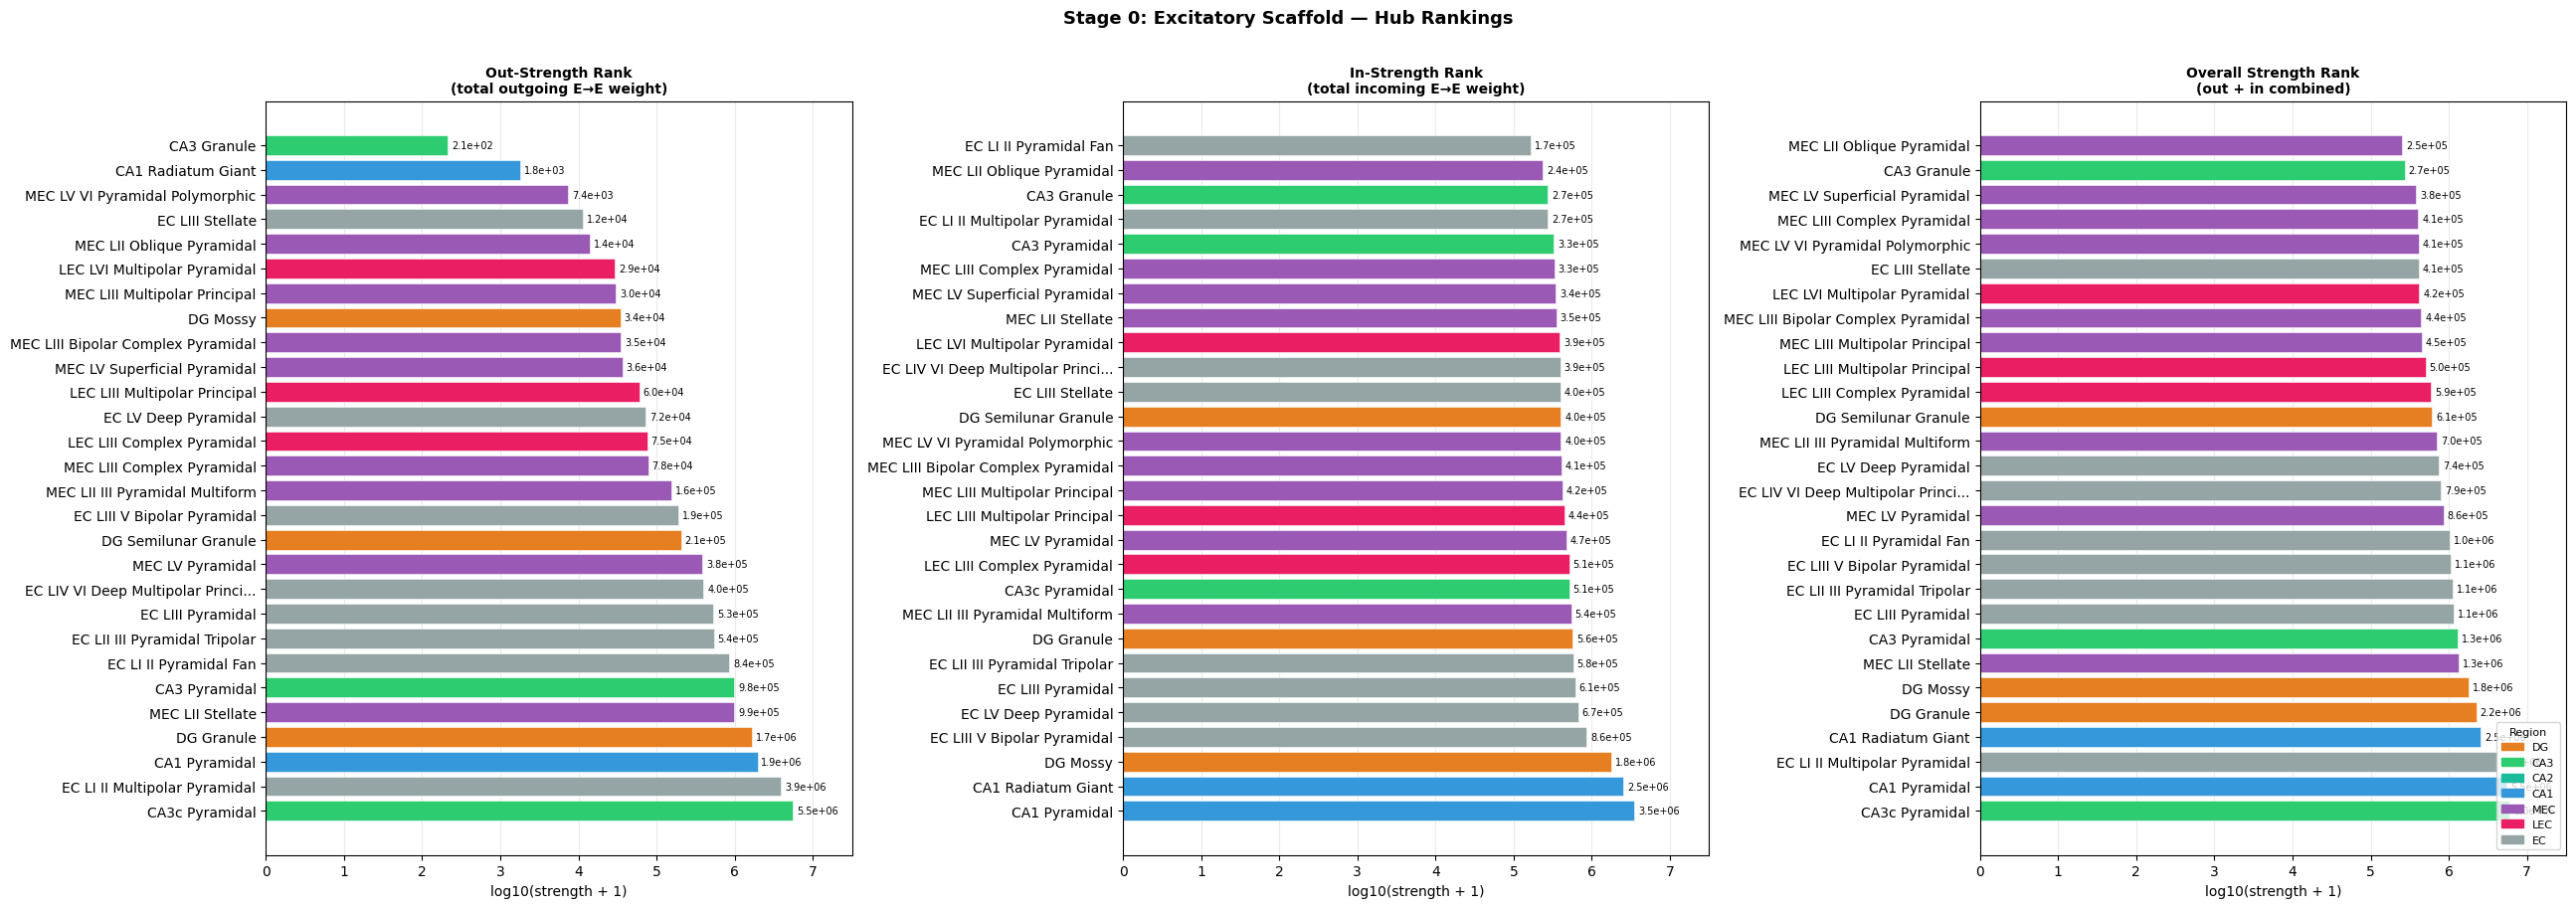

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_hub_rankings.png


In [6]:
# Hub ranking bar chart (out / in / overall)
fig, axes = plt.subplots(1, 3, figsize=(26, 9), sharey=False)
panels = [
    ('out_rank',     'out_strength',     'Out-Strength Rank\n(total outgoing E→E weight)'),
    ('in_rank',      'in_strength',      'In-Strength Rank\n(total incoming E→E weight)'),
    ('overall_rank', 'overall_strength', 'Overall Strength Rank\n(out + in combined)'),
]
for ax, (sort_col, val_col, title) in zip(axes, panels):
    df_plot = rank_df.sort_values(sort_col, ascending=True)
    colors  = [region_colors.get(r, '#7F8C8D') for r in df_plot['region']]
    vals    = df_plot[val_col].values
    names   = [n if len(n) <= 34 else n[:32]+'...' for n in df_plot.index]
    bars    = ax.barh(range(len(names)), np.log10(vals+1), color=colors, edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=10)
    ax.set_xlabel('log10(strength + 1)', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim(0, 7.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'{v:.1e}', va='center', ha='left', fontsize=7)
    ax.grid(axis='x', alpha=0.25)
    ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in region_colors.items() if r != 'Other']
axes[2].legend(handles=legend_patches, title='Region', loc='lower right', fontsize=8, title_fontsize=8)
plt.suptitle('Stage 0: Excitatory Scaffold — Hub Rankings', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage0_hub_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage0_hub_rankings.png')

## 5. PageRank & Markov Stationary Distribution

Both are computed on the 27-node E→E subgraph using raw synaptic weights, which are row-normalized to transition probabilities `P(i→j) = w_ij / Σ_k w_ik`.

**Markov stationary distribution (π):** Long-run fraction of time a random walker spends at each node, solved iteratively via power method. No teleportation.

**PageRank (α=0.85):** Identical row-normalized transitions but with 0.15 teleportation — at each step the walker jumps to a uniformly random node with probability 0.15. This prevents absorption at structural sinks and ensures convergence even without teleportation.

**Key finding:** MEC LV VI Pyramidal Polymorphic is the greedy terminus (Section 6) but ranks *low* under both diffusion metrics. This is not an error — it means the network structurally routes deterministic signal toward it but does not recirculate stochastic activity through it. EC LIV VI Deep Multipolar Principal ranks high under both because it has strong incoming weight from many nodes — it is a genuine diffusive attractor. This disagreement between greedy and diffusion centrality is scientifically informative.

*Note on weight magnitude:* Because weights span ~13 orders of magnitude, row-normalization is effectively winner-take-all at most nodes. PageRank on raw weights therefore behaves nearly identically to the greedy path at each step, differing mainly through teleportation.

In [7]:
# ── Markov transition matrix & stationary distribution ───────────────────────
nodes_list = list(G_exc.nodes())
N_e = len(nodes_list)
node_idx = {n: i for i, n in enumerate(nodes_list)}

# Build row-normalized transition matrix
P = np.zeros((N_e, N_e))
for i, src in enumerate(nodes_list):
    out_w = {v: G_exc[src][v]['weight'] for _, v in G_exc.out_edges(src)}
    total = sum(out_w.values())
    if total > 0:
        for dst, w in out_w.items():
            P[i, node_idx[dst]] = w / total

# Power method for stationary distribution
pi = np.ones(N_e) / N_e
for _ in range(10000):
    pi_new = pi @ P
    if np.max(np.abs(pi_new - pi)) < 1e-12:
        break
    pi = pi_new
pi = pi_new

stationary = pd.Series(pi, index=nodes_list).sort_values(ascending=False)

# ── PageRank ──────────────────────────────────────────────────────────────────
pagerank = pd.Series(
    nx.pagerank(G_exc, weight='weight', alpha=0.85),
    name='pagerank'
).sort_values(ascending=False)

# ── Combined table ────────────────────────────────────────────────────────────
centrality_df = pd.DataFrame({
    'region':      {n: region(n) for n in nodes_list},
    'stationary':  stationary,
    'pagerank':    pagerank,
    'out_strength': rank_df['out_strength'],
})
centrality_df['stat_rank'] = centrality_df['stationary'].rank(ascending=False).astype(int)
centrality_df['pr_rank']   = centrality_df['pagerank'].rank(ascending=False).astype(int)
centrality_df['out_rank']  = rank_df['out_rank']
centrality_df = centrality_df.sort_values('stat_rank')
centrality_df.to_csv(f'{TABLE_DIR}stage0_centrality.csv')

print('Centrality rankings — E→E subgraph')
print(f'{"Neuron":<45} {"Rgn":<5} {"Stat Rank":>9} {"PR Rank":>7} {"Out Rank":>8} {"Stationary":>12} {"PageRank":>12}')
print('-' * 105)
for name, row in centrality_df.iterrows():
    print(f'{name:<45} {row["region"]:<5} {int(row["stat_rank"]):>9} {int(row["pr_rank"]):>7} '
          f'{int(row["out_rank"]):>8} {row["stationary"]:>12.4f} {row["pagerank"]:>12.4f}')
print(f'\nSaved: {TABLE_DIR}stage0_centrality.csv')

Centrality rankings — E→E subgraph
Neuron                                        Rgn   Stat Rank PR Rank Out Rank   Stationary     PageRank
---------------------------------------------------------------------------------------------------------
DG Mossy                                      DG            1       1       21       0.2519       0.1109
DG Granule                                    DG            2       2        4       0.1775       0.0852
DG Semilunar Granule                          DG            3       6       12       0.1012       0.0522
EC LIV VI Deep Multipolar Principal           EC            4       3       10       0.0441       0.0609
EC LV Deep Pyramidal                          EC            5       4       17       0.0417       0.0582
EC LIII V Bipolar Pyramidal                   EC            6       5       13       0.0372       0.0541
MEC LIII Multipolar Principal                 MEC           7       7       22       0.0324       0.0498
CA1 Pyramidal      

## 6. Greedy Path Functions

Three variants of greedy path tracing are implemented:

- **Variant A (Stop):** Follow the highest-weight available unvisited edge. Stop when every greedy next step would revisit a node already in the path. Returns the terminus and diagnosis.
- **Variant B (Skip):** Same as A, but when a revisit would occur, skip it (record as a side loop) and continue to the next unvisited option. Stops when no unvisited targets remain.
- **Variant C (Edge Exhaustion):** Each directed edge may be traversed at most once; nodes can be revisited freely. Stops when no unused outgoing edges remain from the current node.

**Implementation notes:**
- `max_steps = N_e - 1 = 26` — must be at least this to avoid silently truncating paths before natural terminus
- Dijkstra cost uses `log(w_max/w)` (always ≥ 0) not `-log(w)` (negative for w > 1)

In [8]:
def greedy_path_with_diagnosis(G, start, max_steps=None):
    """Variant A: stop on revisit. Returns (path, edge_weights, reason, peek_dict)."""
    if max_steps is None:
        max_steps = G.number_of_nodes() - 1
    path = [start]; edge_weights = []; visited = {start}; current = start
    for _ in range(max_steps):
        out_edges = [(v, d['weight']) for _, v, d in G.out_edges(current, data=True)]
        if not out_edges:
            return path, edge_weights, 'dead end (no outgoing edges)', {}
        unvisited = [(v, w) for v, w in out_edges if v not in visited]
        if not unvisited:
            best_v, best_w = max(out_edges, key=lambda x: x[1])
            self_w = G[current][current]['weight'] if G.has_edge(current, current) else None
            return path, edge_weights, 'cycle - would return to already-visited node', {
                'would_go_to': best_v, 'would_go_weight': best_w, 'self_weight': self_w}
        best_v, best_w = max(unvisited, key=lambda x: x[1])
        path.append(best_v); edge_weights.append(best_w)
        visited.add(best_v); current = best_v
    return path, edge_weights, f'max steps ({max_steps}) reached', {}


def greedy_path_skip_loops(G, start, max_steps=None):
    """Variant B: skip revisit targets, record as side loops, continue."""
    if max_steps is None:
        max_steps = G.number_of_nodes() - 1
    path = [start]; edge_weights = []; side_loops = []; visited = {start}; current = start
    for _ in range(max_steps):
        out_edges = [(v, d['weight']) for _, v, d in G.out_edges(current, data=True)]
        if not out_edges:
            return path, edge_weights, 'dead end', {}, side_loops
        unvisited = [(v, w) for v, w in out_edges if v not in visited]
        revisits  = [(v, w) for v, w in out_edges if v in visited]
        if revisits:
            br = max(revisits, key=lambda x: x[1])
            side_loops.append((current, br[0], br[1]))
        if not unvisited:
            best_v, best_w = max(out_edges, key=lambda x: x[1])
            self_w = G[current][current]['weight'] if G.has_edge(current, current) else None
            return path, edge_weights, 'exhausted - no unvisited targets remain', {
                'would_go_to': best_v, 'would_go_weight': best_w, 'self_weight': self_w}, side_loops
        best_v, best_w = max(unvisited, key=lambda x: x[1])
        path.append(best_v); edge_weights.append(best_w)
        visited.add(best_v); current = best_v
    return path, edge_weights, f'max steps ({max_steps}) reached', {}, side_loops


def greedy_path_allow_revisits(G, start):
    """Variant C: each directed edge used at most once; nodes freely revisited."""
    path = [start]; edge_weights = []; used_edges = set()
    visit_counts = defaultdict(int); visit_counts[start] = 1
    current = start
    while True:
        available = [(v, d['weight']) for _, v, d in G.out_edges(current, data=True)
                     if (current, v) not in used_edges]
        if not available:
            reason = 'exhausted - no unused outgoing edges from current node'
            break
        best_v, best_w = max(available, key=lambda x: x[1])
        used_edges.add((current, best_v))
        visit_counts[best_v] += 1
        path.append(best_v); edge_weights.append(best_w); current = best_v
    return path, edge_weights, reason, visit_counts


# Run all three variants for all 27 starting nodes
paths_A, weights_A, reasons_A, peeks_A = {}, {}, {}, {}
paths_B, weights_B, reasons_B, peeks_B, loops_B = {}, {}, {}, {}, {}

for n in excitatory:
    p, w, r, pk         = greedy_path_with_diagnosis(G_exc, n)
    paths_A[n], weights_A[n], reasons_A[n], peeks_A[n] = p, w, r, pk
    p2, w2, r2, pk2, sl = greedy_path_skip_loops(G_exc, n)
    paths_B[n], weights_B[n], reasons_B[n], peeks_B[n], loops_B[n] = p2, w2, r2, pk2, sl

print('Variant A terminus distribution:')
for r, cnt in pd.Series({n: reasons_A[n] for n in excitatory}).value_counts().items():
    print(f'  {cnt:2d}/27  {r}')

Variant A terminus distribution:
  28/27  cycle - would return to already-visited node


## 7. Terminus Diagnosis & Path Rankings

Each Variant A path is diagnosed for *why* it stopped and *where it would have gone* if allowed to revisit nodes:

- **Dead end:** The current node has no outgoing E→E edges.
- **Cycle — would revisit:** The greedy next step points to an already-visited node. The `would_go_to` field records this attempted target — revealing the structural attractor pair.
- **Max steps:** The `max_steps` cap was reached (should not occur with `max_steps = N−1`).

**Key finding:** 26/27 starting nodes terminate at MEC LV VI Pyramidal Polymorphic. For nearly all of these, the `would_go_to` node is EC LIV VI Deep Multipolar Principal — it would recirculate there if allowed. This pair constitutes the dominant structural attractor of the excitatory scaffold.

In [9]:
# ── Inhibitory sidechain helper ──────────────────────────────────────────────
def inhibitory_sidechain(e_node, W, inhibitory, excitatory):
    """For a given E node, find the strongest E->I target and what that I node most suppresses."""
    e_to_i = W.loc[e_node, inhibitory]
    valid  = e_to_i[e_to_i > 0]
    if valid.empty:
        return None
    top_i   = valid.idxmax()
    top_i_w = valid.max()
    # Restrict suppression lookup to excitatory nodes only
    i_to_e = W.loc[top_i, excitatory]
    neg    = i_to_e[i_to_e < 0]
    most_suppressed = neg.idxmin() if not neg.empty else None
    suppress_w      = neg.min()    if not neg.empty else None
    return {
        'top_i_neuron':  top_i,
        'top_i_weight':  top_i_w,
        'most_suppressed': most_suppressed,
        'suppress_weight': suppress_w,
    }


# ── Build Variant A path table with inhibitory sidechain annotation ───────────
records = []
for start in excitatory:
    path, weights, reason, peek = greedy_path_with_diagnosis(G_exc, start)
    for step_idx, node in enumerate(path):
        edge_w = weights[step_idx-1] if step_idx > 0 else None
        sc     = inhibitory_sidechain(node, W, inhibitory, excitatory)
        is_last = (step_idx == len(path) - 1)
        records.append({
            'path_start':     start,
            'step':           step_idx,
            'e_node':         node,
            'region':         region(node),
            'edge_weight':    edge_w,
            'is_terminus':    is_last,
            'terminus_reason': reason if is_last else '',
            'would_go_to':    peek.get('would_go_to', '') if is_last else '',
            'would_go_weight': peek.get('would_go_weight', np.nan) if is_last else np.nan,
            'top_i_neuron':   sc['top_i_neuron']   if sc else '',
            'top_i_weight':   sc['top_i_weight']   if sc else np.nan,
            'most_suppressed': sc['most_suppressed'] if sc else '',
            'suppress_weight': sc['suppress_weight'] if sc else np.nan,
        })

df_paths = pd.DataFrame(records)
df_paths.to_csv(f'{TABLE_DIR}stage0_variantA_paths.csv', index=False)
print(f'Rows: {len(df_paths)} | Paths: {df_paths["path_start"].nunique()}')

# Terminus and would-go-to distributions
print('\nTerminus distribution (Variant A):')
for t, c in df_paths[df_paths['is_terminus']]['e_node'].value_counts().items():
    print(f'  {c:2d}/27  {t}')

print('\nWould-go-to at terminus (Variant A):')
wgt = df_paths[df_paths['is_terminus']]['would_go_to'].value_counts()
for t, c in wgt.items():
    if t: print(f'  {c:2d}/27  -> {t}')

print(f'\nSaved: {TABLE_DIR}stage0_variantA_paths.csv')

Rows: 421 | Paths: 28

Terminus distribution (Variant A):
  13/27  MEC LV VI Pyramidal Polymorphic
   8/27  CA1 Radiatum Giant
   5/27  DG Semilunar Granule
   1/27  CA3 Granule
   1/27  CA1 Pyramidal

Would-go-to at terminus (Variant A):
  13/27  -> EC LIV VI Deep Multipolar Principal
   8/27  -> CA1 Pyramidal
   5/27  -> DG Mossy
   1/27  -> CA3c Pyramidal
   1/27  -> EC LV Deep Pyramidal

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_variantA_paths.csv


In [10]:
# ── Key path printouts with inhibitory sidechain annotation ───────────────────
KEY_STARTS = ['MEC LII Stellate', 'DG Granule', 'CA3 Pyramidal', 'CA3c Pyramidal', 'CA1 Pyramidal']

for start in KEY_STARTS:
    sub = df_paths[df_paths['path_start'] == start].sort_values('step')
    if sub.empty: continue
    print('=' * 115)
    print(f'PATH FROM: {start}')
    print(f'{"Step":<5} {"E Node":<38} {"->E weight":>12} | {"Top I target":<33} {"E->I w":>10}  ->suppresses->  {"I->E w":>10}')
    print('-' * 115)
    for _, row in sub.iterrows():
        e_arrow = f'->[{row["edge_weight"]:.2e}]' if pd.notna(row['edge_weight']) else '(start) '
        top_i   = row['top_i_neuron']    if row['top_i_neuron']    else '-'
        top_i_w = f'{row["top_i_weight"]:.2e}' if pd.notna(row['top_i_weight']) else ''
        suppd   = row['most_suppressed'] if row['most_suppressed'] else '-'
        supp_w  = f'{row["suppress_weight"]:.2e}' if pd.notna(row['suppress_weight']) else ''
        print(f'{int(row["step"]):<5} {row["e_node"]:<38} {e_arrow:>12} | {top_i:<33} {top_i_w:>10}  {suppd:<35}  {supp_w:>10}')
        if row['is_terminus']:
            wgo = f'{row["would_go_weight"]:.2e}' if pd.notna(row['would_go_weight']) else 'n/a'
            print(f'  -> TERMINUS: {row["terminus_reason"]}')
            if row['would_go_to']:
                print(f'     Would return to: {row["would_go_to"]} (weight {wgo})')
    print()

PATH FROM: MEC LII Stellate
Step  E Node                                   ->E weight | Top I target                          E->I w  ->suppresses->      I->E w
-------------------------------------------------------------------------------------------------------------------
0     MEC LII Stellate                           (start)  | CA3 Basket                          1.75e+05  CA3 Pyramidal                         -1.37e+04
1     CA3 Pyramidal                          ->[2.73e+05] | CA1 Recurrent O LM                  2.08e+06  CA1 Pyramidal                         -1.77e+02
2     CA3c Pyramidal                         ->[3.96e+05] | CA1 OR LM                           2.98e+06  CA1 Radiatum Giant                    -3.26e+02
3     CA1 Pyramidal                          ->[2.95e+06] | CA1 Recurrent O LM                  1.73e+05  CA1 Pyramidal                         -1.77e+02
4     EC LV Deep Pyramidal                   ->[3.47e+05] | -                                             -

## 8. Path Rankings — All 27 Starting Nodes

Ranked by Variant A total edge-weight sum. Also reports Variant C length and weight sum for comparison.
**SideLoops** = number of times Variant B skipped a revisit (each corresponds to a labeled short cycle).

In [11]:
path_ranks = []
for n in excitatory:
    sum_A  = sum(weights_A[n]) if weights_A[n] else 0
    p_C, w_C, r_C, _ = greedy_path_allow_revisits(G_exc, n)
    sum_C  = sum(w_C)
    path_ranks.append({
        'start':          n,
        'region':         region(n),
        'len_A':          len(paths_A[n]),
        'weight_sum_A':   sum_A,
        'terminus_A':     paths_A[n][-1],
        'n_side_loops_B': len(loops_B[n]),
        'len_C':          len(p_C) - 1,
        'weight_sum_C':   sum_C,
        'terminus_C':     p_C[-1],
    })

path_df = pd.DataFrame(path_ranks).sort_values('weight_sum_A', ascending=False).reset_index(drop=True)
path_df.index += 1
path_df.to_csv(f'{TABLE_DIR}stage0_path_rankings.csv', index=True)

print('All 27 paths ranked by Variant A total edge-weight sum:')
print(f'{"Rank":<5} {"Start":<45} {"Rgn":<5} {"LenA":>5} {"SumA":>14} {"Terminus A":<38} {"Loops":>5} {"LenC":>5} {"SumC":>14} {"Terminus C"}')
print('-' * 175)
for i, row in path_df.iterrows():
    print(f'{i:<5} {row["start"]:<45} {row["region"]:<5} {int(row["len_A"]):>5} '
          f'{row["weight_sum_A"]:>14.3e} {row["terminus_A"]:<38} {int(row["n_side_loops_B"]):>5} '
          f'{int(row["len_C"]):>5} {row["weight_sum_C"]:>14.3e} {row["terminus_C"]}')
print(f'\nSaved: {TABLE_DIR}stage0_path_rankings.csv')

All 27 paths ranked by Variant A total edge-weight sum:
Rank  Start                                         Rgn    LenA           SumA Terminus A                             Loops  LenC           SumC Terminus C
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     MEC LIII Bipolar Complex Pyramidal            MEC      18      5.835e+06 DG Semilunar Granule                      14    73      1.217e+07 MEC LV VI Pyramidal Polymorphic
2     MEC LII Oblique Pyramidal                     MEC      18      5.831e+06 DG Semilunar Granule                      14    73      1.217e+07 MEC LV VI Pyramidal Polymorphic
3     MEC LIII Complex Pyramidal                    MEC      17      5.826e+06 DG Semilunar Granule                      13    72      1.216e+07 MEC LV VI Pyramidal Polymorphic
4     MEC LII Stellate                              MEC      16      5.814e+06 DG

## 9. Short Excitatory Cycle Enumeration (Lengths 2–4)

Cycles are labeled hierarchically as `L{length}.{rank}` (e.g., L2.1 = top reciprocal pair, L3.4 = the 4th triangle). If a cycle is a superset of a shorter one, it records which shorter cycle it 'extends'.

These labels are cross-referenced in Variant B and Variant C path printouts to annotate which side loops correspond to which cycles.

**Key cycle:** DG Granule → CA3c → CA1 → MEC LV Pyramidal → DG Granule (weight ~3.36×10⁶) — validates the classic trisynaptic circuit.

In [12]:
all_cycles = list(nx.simple_cycles(G_exc, length_bound=4))
cycle_records = []
for cyc in all_cycles:
    L = len(cyc)
    if L < 2 or L > 4: continue
    total_w = sum(G_exc[cyc[i]][cyc[(i+1) % L]]['weight'] for i in range(L))
    rgns    = ' -> '.join(region(n) for n in cyc)
    cycle_records.append({'length': L, 'nodes': ' -> '.join(cyc) + f' -> {cyc[0]}',
                          'weight_sum': total_w, 'regions': rgns})

cycle_df = pd.DataFrame(cycle_records).sort_values(['length','weight_sum'], ascending=[True, False]).reset_index(drop=True)

for L in [2, 3, 4]:
    mask = cycle_df['length'] == L
    cycle_df.loc[mask, 'label'] = [f'L{L}.{i+1}' for i in range(mask.sum())]

cycle_df['node_set'] = cycle_df['nodes'].apply(lambda s: frozenset(s.split(' -> ')[:-1]))

def find_parent(row, cycle_df):
    if row['length'] == 2: return ''
    for _, sr in cycle_df[cycle_df['length'] == row['length'] - 1].iterrows():
        if sr['node_set'].issubset(row['node_set']): return sr['label']
    return ''

cycle_df['extends'] = cycle_df.apply(lambda row: find_parent(row, cycle_df), axis=1)

print(f'Short cycles found: {len(cycle_df)} total')
for L in [2, 3, 4]:
    sub = cycle_df[cycle_df['length'] == L]
    print(f'\nLength-{L} cycles ({len(sub)} total) — top 10:')
    print(f'  {"Label":<8} {"Extends":<10} {"Weight Sum":>14} {"Regions":<25} Nodes')
    print('  ' + '-' * 90)
    for _, row in sub.head(10).iterrows():
        ext = f'<- {row["extends"]}' if row['extends'] else ''
        print(f'  {row["label"]:<8} {ext:<10} {row["weight_sum"]:>14.3e} {row["regions"]:<25} {row["nodes"][:60]}')

cycle_df[['label','extends','length','weight_sum','regions','nodes']].to_csv(
    f'{TABLE_DIR}stage0_cycles_labeled.csv', index=False)

# Build edge->cycle lookup for Variant C annotations
edge_to_cycles = defaultdict(list)
for _, row in cycle_df.iterrows():
    nodes_in = row['nodes'].split(' -> ')[:-1]
    for i in range(len(nodes_in)):
        u = nodes_in[i]; v = nodes_in[(i+1) % len(nodes_in)]
        edge_to_cycles[(u, v)].append(row['label'])

print(f'\nSaved: {TABLE_DIR}stage0_cycles_labeled.csv')
print(f'Edge->cycle lookup: {len(edge_to_cycles)} edges participate in at least one short cycle')

Short cycles found: 6313 total

Length-2 cycles (109 total) — top 10:
  Label    Extends        Weight Sum Regions                   Nodes
  ------------------------------------------------------------------------------------------
  L2.1                     1.570e+06 DG -> DG                  DG Mossy -> DG Granule -> DG Mossy
  L2.2                     5.725e+05 EC -> EC                  EC LI II Multipolar Pyramidal -> EC LII III Pyramidal Tripol
  L2.3                     4.268e+05 CA3 -> CA3                CA3c Pyramidal -> CA3 Pyramidal -> CA3c Pyramidal
  L2.4                     3.942e+05 EC -> MEC                 EC LI II Multipolar Pyramidal -> MEC LII III Pyramidal Multi
  L2.5                     3.732e+05 EC -> LEC                 EC LI II Multipolar Pyramidal -> LEC LIII Complex Pyramidal 
  L2.6                     3.230e+05 EC -> MEC                 EC LI II Multipolar Pyramidal -> MEC LIII Bipolar Complex Py
  L2.7                     2.729e+05 EC -> EC                

## 10. Greedy Edge Cover

Minimum set of Variant C tours needed to traverse all 268 E→E edges at least once. At each step, the starting node is chosen greedily as the node with the most uncovered outgoing edges.

**Result:** 55 tours total. Tour 1 alone covers 54 edges (20%) — evidence of a dense structural core vs. sparse periphery.

In [ ]:
def greedy_edge_cover(G, excitatory):
    all_edges = set((u, v) for u, v in G.edges()); covered = set(); tours = []
    while covered < all_edges:
        uncovered_out = {n: sum(1 for _, v in G.out_edges(n) if (n, v) not in covered)
                         for n in excitatory}
        best_start = max(uncovered_out, key=uncovered_out.get)
        if uncovered_out[best_start] == 0: break
        path = [best_start]; weights = []; used_this_tour = set(); current = best_start
        while True:
            available = [(v, d['weight']) for _, v, d in G.out_edges(current, data=True)
                         if (current, v) not in covered]
            if not available: break
            best_v, best_w = max(available, key=lambda x: x[1])
            used_this_tour.add((current, best_v))
            path.append(best_v); weights.append(best_w); current = best_v
        covered |= used_this_tour
        tours.append({'start': best_start, 'path': path, 'weights': weights,
                      'edges_covered': len(used_this_tour), 'total_covered': len(covered)})
        print(f'Tour {len(tours):>2}: start={best_start:<40} edges_this_tour={len(used_this_tour):>3} '
              f'total={len(covered)}/{len(all_edges)}')
    print(f'\nTotal tours needed: {len(tours)} | Edges covered: {len(covered)}/{len(all_edges)}')
    return tours

tours = greedy_edge_cover(G_exc, excitatory)

## 11. Visualizations

All figures are saved to the `TABLE_DIR` output folder.

### 11.1 Weight Matrix Heatmaps

Signed log scale: red = excitatory drive, blue = inhibitory suppression. Yellow line on the 72×72 heatmap separates E (top-left block) from I (bottom-right) neurons.

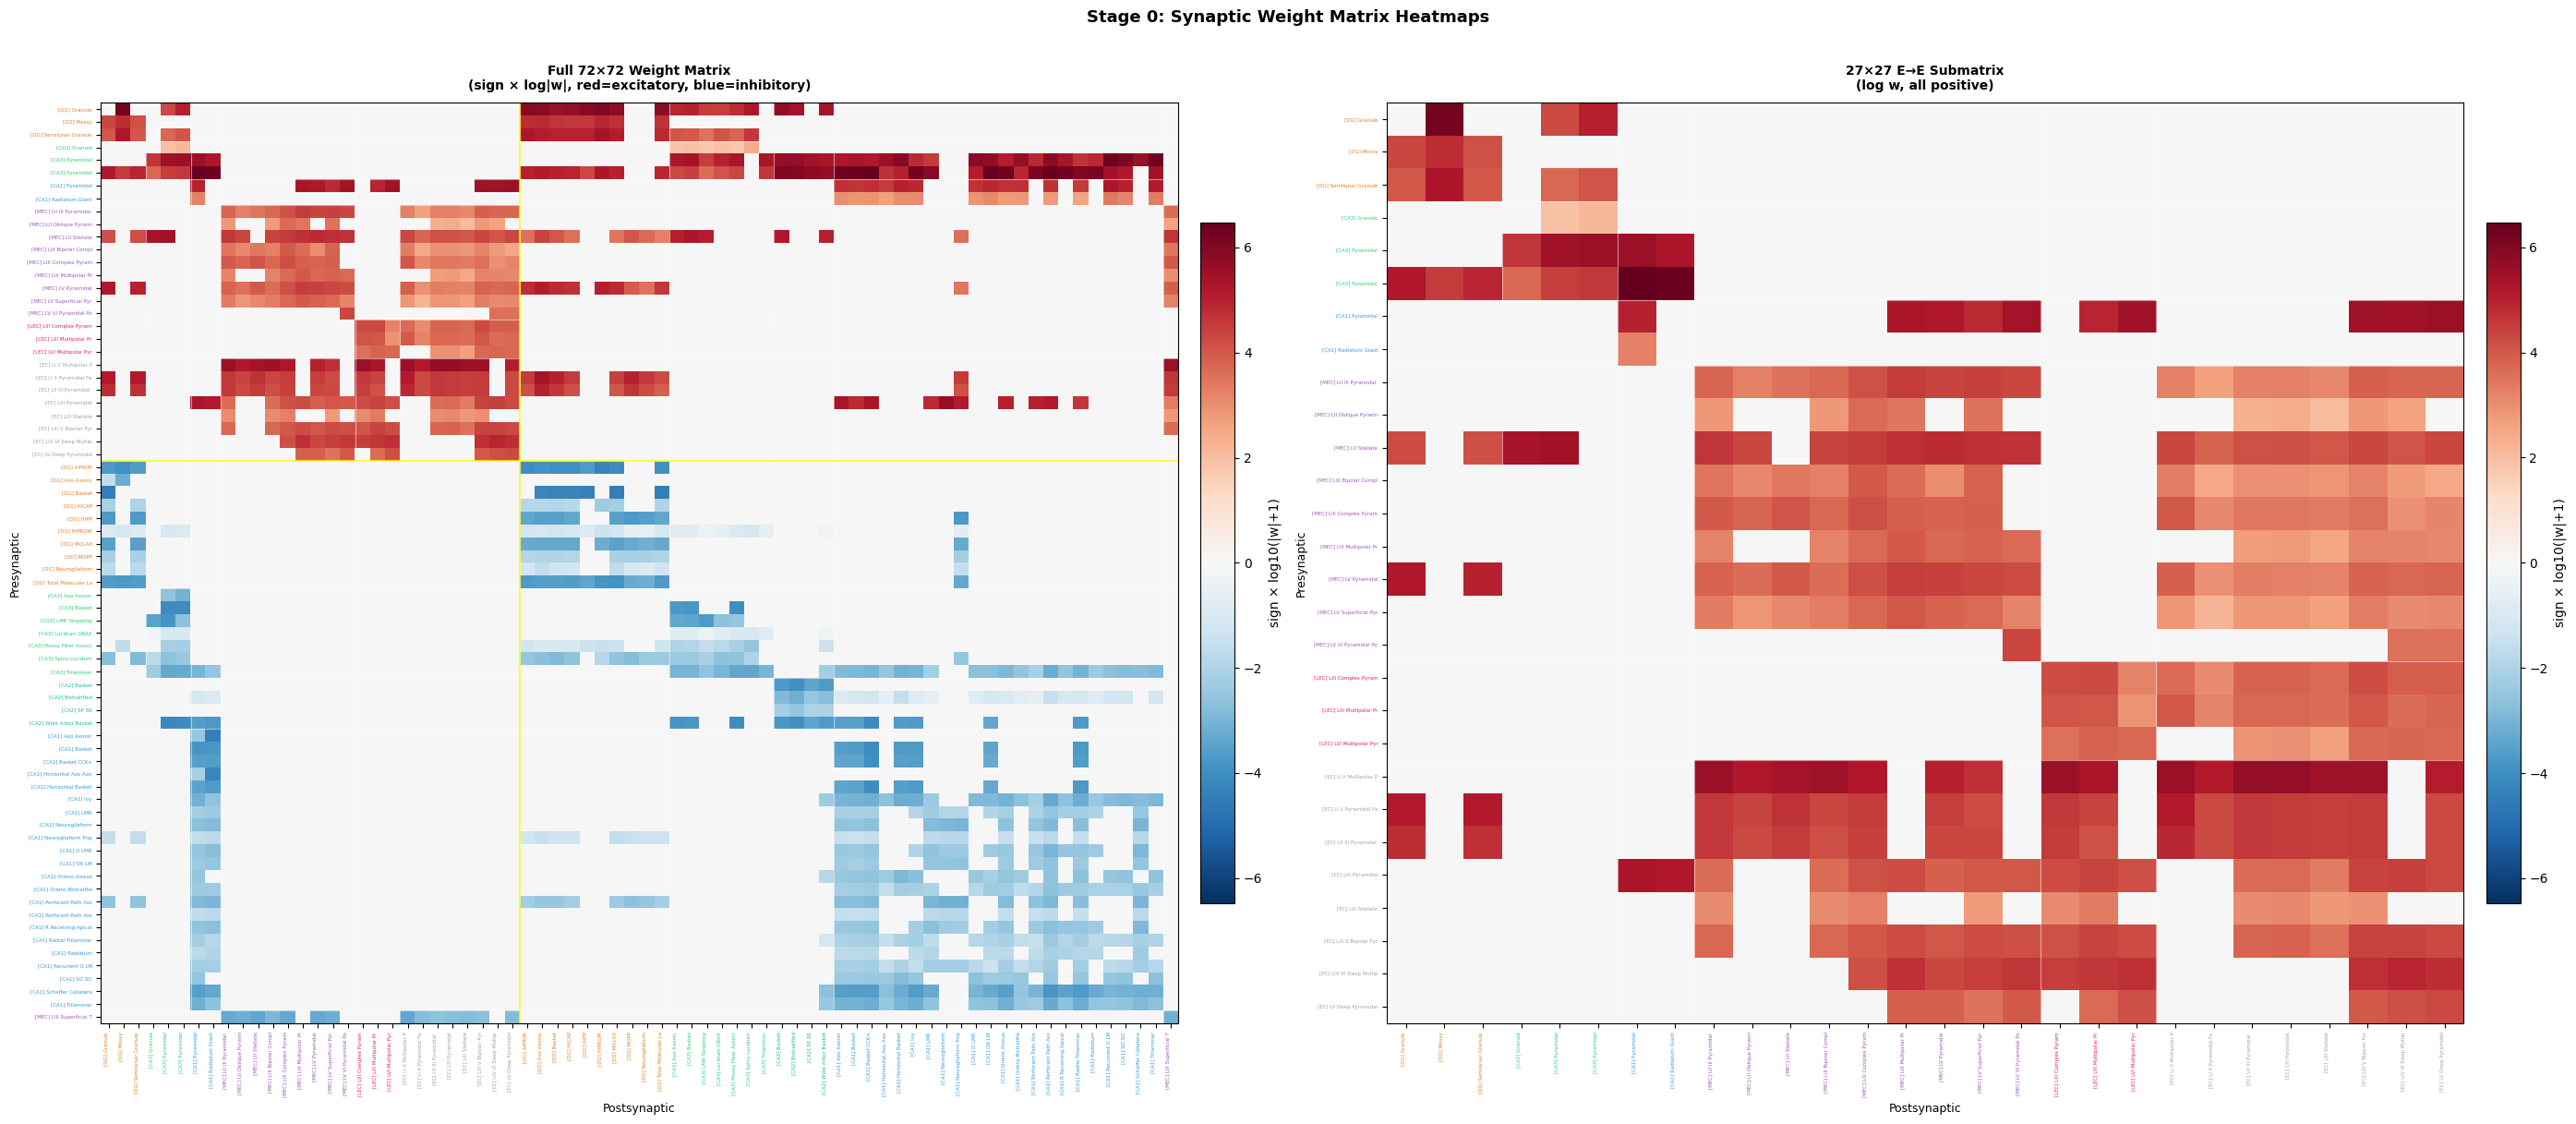

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_weight_matrix_heatmaps.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(28, 12))
sorted_72 = sorted(w_nodes, key=lambda n: (0 if ei_lookup.get(n) == 'e' else 1,
                                           region_order_list.index(region(n))
                                           if region(n) in region_order_list else 99, n))
sorted_27 = sorted(excitatory, key=lambda n: (region_order_list.index(region(n))
                                              if region(n) in region_order_list else 99, n))

for ax, nodes, title, mat in [
    (axes[0], sorted_72, 'Full 72×72 Weight Matrix\n(sign × log|w|, red=excitatory, blue=inhibitory)', W.loc[sorted_72, sorted_72]),
    (axes[1], sorted_27, '27×27 E→E Submatrix\n(log w, all positive)', W_exc.loc[sorted_27, sorted_27]),
]:
    raw  = mat.values.copy()
    sgns = np.sign(raw)
    lw   = np.where(raw != 0, sgns * np.log10(np.abs(raw) + 1), 0)
    im   = ax.imshow(lw, cmap='RdBu_r', aspect='auto', vmin=-np.abs(lw).max(), vmax=np.abs(lw).max())
    plt.colorbar(im, ax=ax, label='sign × log10(|w|+1)', fraction=0.03, pad=0.02)
    fs          = 5.5 if len(nodes) == 27 else 4.0
    short_names = [f'[{region(n)}] {n.split(" ",1)[-1][:18]}' for n in nodes]
    ax.set_xticks(range(len(nodes))); ax.set_xticklabels(short_names, rotation=90, fontsize=fs, ha='right')
    ax.set_yticks(range(len(nodes))); ax.set_yticklabels(short_names, fontsize=fs)
    for xt, yt, node in zip(ax.get_xticklabels(), ax.get_yticklabels(), nodes):
        c = region_colors.get(region(node), '#7F8C8D'); xt.set_color(c); yt.set_color(c)
    current_rgn = region(nodes[0])
    for idx, n in enumerate(nodes):
        if region(n) != current_rgn:
            ax.axhline(idx-0.5, color='white', lw=0.8, alpha=0.5)
            ax.axvline(idx-0.5, color='white', lw=0.8, alpha=0.5)
            current_rgn = region(n)
    if len(nodes) == 72:
        n_e = sum(1 for n in nodes if ei_lookup.get(n) == 'e')
        ax.axhline(n_e-0.5, color='yellow', lw=1.5, alpha=0.7)
        ax.axvline(n_e-0.5, color='yellow', lw=1.5, alpha=0.7)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Postsynaptic', fontsize=9)
    ax.set_ylabel('Presynaptic', fontsize=9)

plt.suptitle('Stage 0: Synaptic Weight Matrix Heatmaps', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage0_weight_matrix_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage0_weight_matrix_heatmaps.png')

### 11.2 Region-Level Flow Heatmap

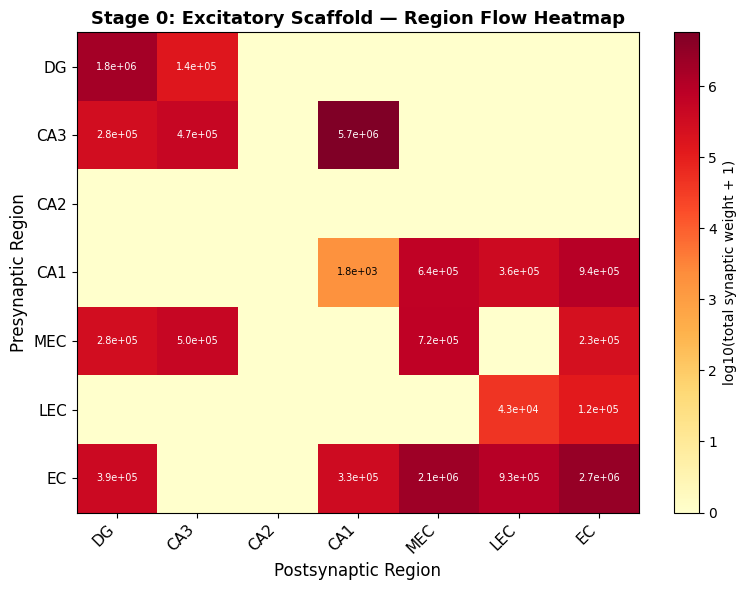

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_region_heatmap.png


In [15]:
regions = ['DG', 'CA3', 'CA2', 'CA1', 'MEC', 'LEC', 'EC']
region_flow = pd.DataFrame(0.0, index=regions, columns=regions)
for pre, post, d in G_exc.edges(data=True):
    r_pre = region(pre); r_post = region(post)
    if r_pre in regions and r_post in regions:
        region_flow.loc[r_pre, r_post] += d['weight']

log_flow = np.log10(region_flow + 1)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(log_flow.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='log10(total synaptic weight + 1)')
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(len(regions))); ax.set_yticklabels(regions, fontsize=11)
ax.set_xlabel('Postsynaptic Region', fontsize=12)
ax.set_ylabel('Presynaptic Region', fontsize=12)
ax.set_title('Stage 0: Excitatory Scaffold — Region Flow Heatmap', fontsize=13, fontweight='bold')
for i in range(len(regions)):
    for j in range(len(regions)):
        val = region_flow.values[i, j]
        if val > 0:
            c = 'white' if log_flow.values[i, j] > log_flow.values.max()*0.6 else 'black'
            ax.text(j, i, f'{val:.1e}', ha='center', va='center', fontsize=7, color=c)
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage0_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage0_region_heatmap.png')

### 11.3 Trisynaptic Circuit Graph

Region-level flow graph with canonical trisynaptic circuit edges highlighted in red. Edge width is proportional to log total synaptic weight.

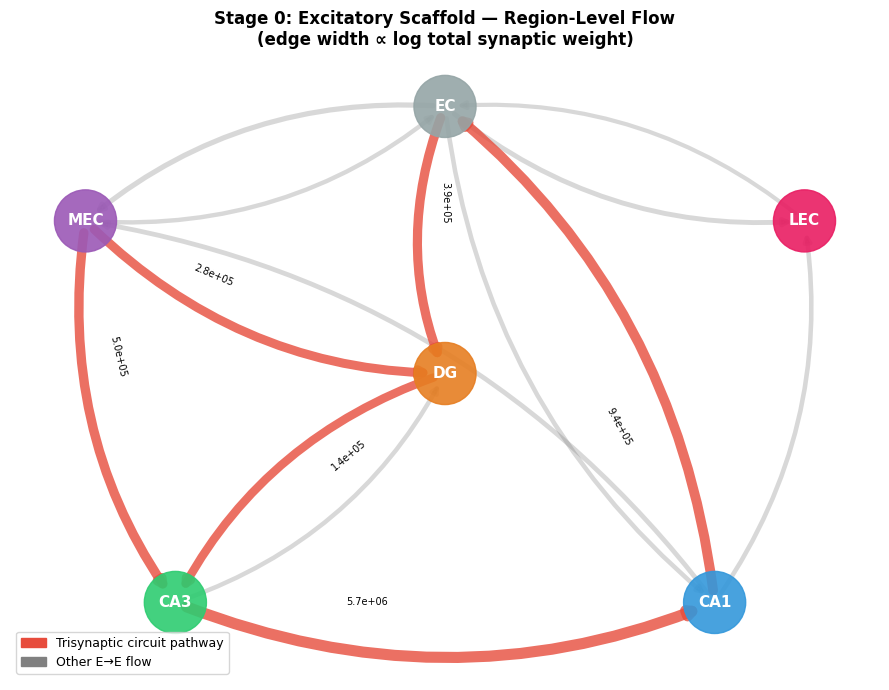

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_region_graph.png


In [18]:
G_region = nx.DiGraph()
for r_pre in regions:
    for r_post in regions:
        w = region_flow.loc[r_pre, r_post]
        if w > 0 and r_pre != r_post:
            G_region.add_edge(r_pre, r_post, weight=w)

pos = {'EC':  (0.5, 1.0), 'MEC': (0.1, 0.85), 'LEC': (0.9, 0.85),
       'DG':  (0.5, 0.65), 'CA3': (0.2, 0.35), 'CA2': (0.5, 0.35), 'CA1': (0.8, 0.35)}
tsc_edges = [('EC','DG'),('EC','CA3'),('DG','CA3'),('CA3','CA1'),('CA2','CA1'),
             ('CA1','EC'),('MEC','DG'),('MEC','CA3')]
all_reg_edges = list(G_region.edges())
highlight = [e for e in all_reg_edges if e in tsc_edges]
other_e   = [e for e in all_reg_edges if e not in tsc_edges]
max_w = max(G_region[u][v]['weight'] for u, v in all_reg_edges)

def norm_width(edges, scale=8):
    return [np.log10(G_region[u][v]['weight']+1) / np.log10(max_w+1) * scale for u, v in edges]

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#F8F9FA')
# Use connectionstyle to draw curved arrows for better visibility of bidirectional edges
if other_e:   nx.draw_networkx_edges(G_region, pos, edgelist=other_e,   ax=ax, width=norm_width(other_e,   4), alpha=0.3, edge_color='gray', arrows=True, connectionstyle='arc3,rad=0.2')
if highlight: nx.draw_networkx_edges(G_region, pos, edgelist=highlight, ax=ax, width=norm_width(highlight, 8), alpha=0.8, edge_color='#E74C3C', arrows=True, connectionstyle='arc3,rad=0.2')
node_c = [region_colors.get(r, '#2E86AB') for r in G_region.nodes()]
nx.draw_networkx_nodes(G_region, pos, ax=ax, node_size=2000, node_color=node_c, alpha=0.9)
nx.draw_networkx_labels(G_region, pos, ax=ax, font_size=11, font_color='white', font_weight='bold')
edge_labels = {(u,v): f'{G_region[u][v]["weight"]:.1e}' for u,v in highlight}
nx.draw_networkx_edge_labels(G_region, pos, edge_labels=edge_labels, ax=ax, font_size=7, label_pos=0.35)
ax.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='Trisynaptic circuit pathway'),
    mpatches.Patch(color='gray',    label='Other E→E flow'),
], loc='lower left', fontsize=9)
ax.set_title('Stage 0: Excitatory Scaffold — Region-Level Flow\n(edge width ∝ log total synaptic weight)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage0_region_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage0_region_graph.png')

### 11.4 Variant C — Node Visit Frequency Heatmap

Since Variant C revisits nodes, a linear path is unreadable. Instead: rows = starting node, columns = E node visited, color = visit count. Columns that are consistently dark across many starting nodes are structural hubs visited regardless of entry point.

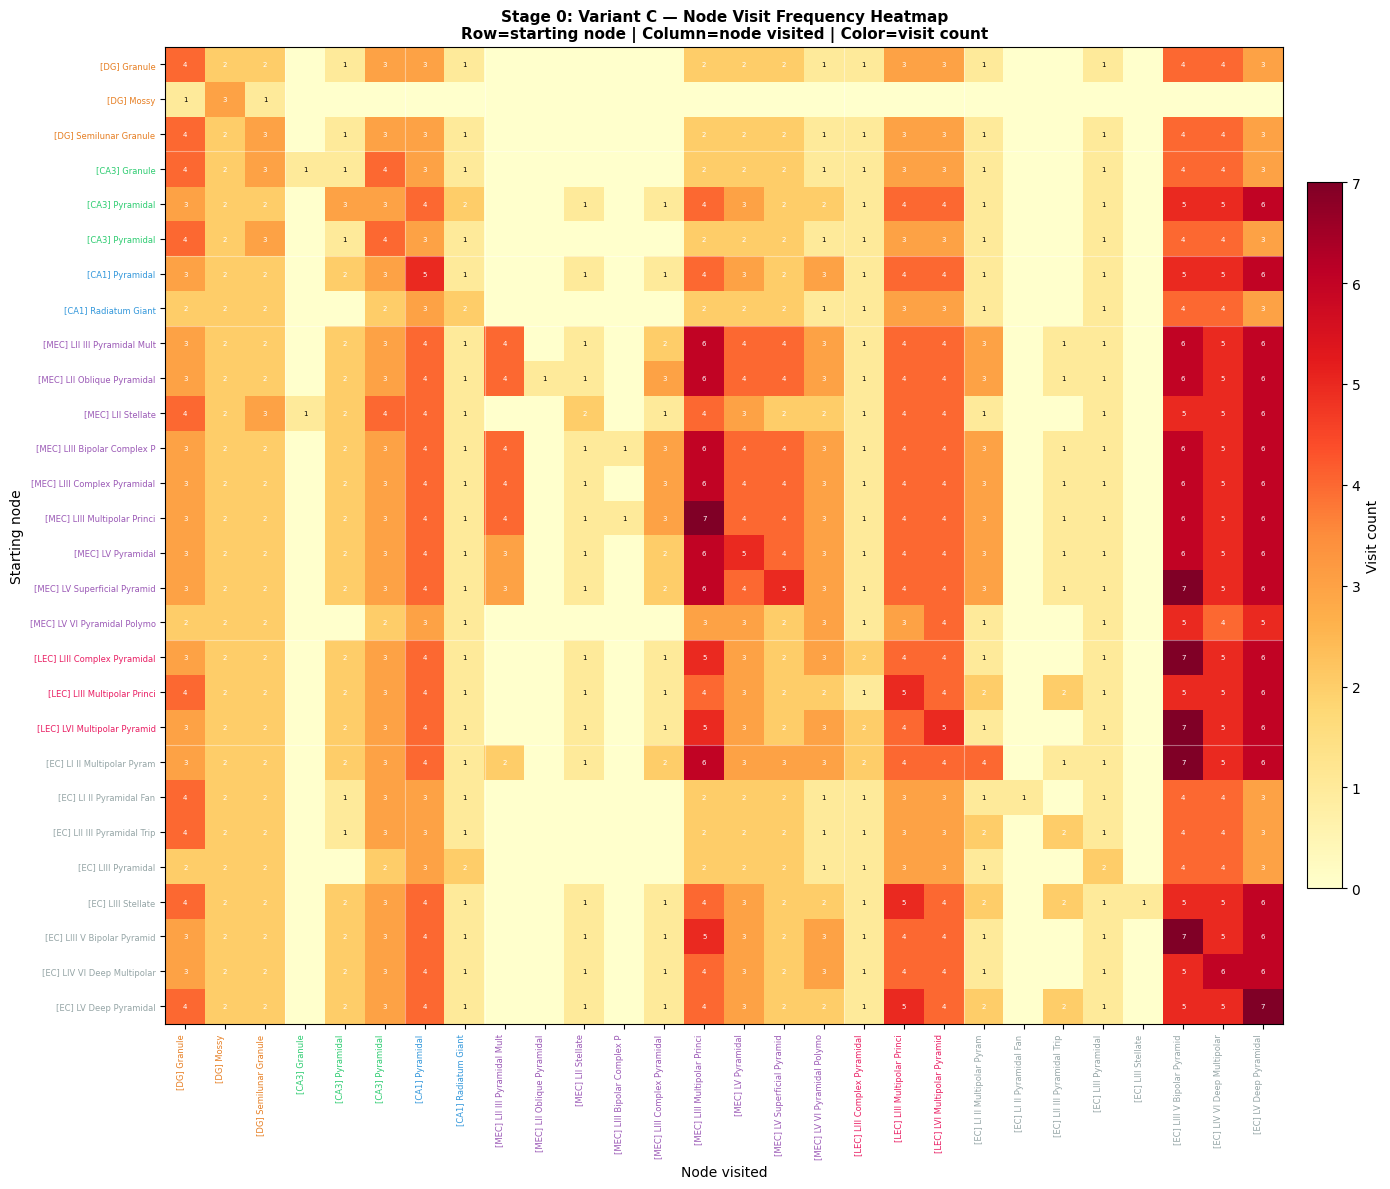

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/scaffolds/stage0_variantC_visit_heatmap.png


In [17]:
visit_matrix = pd.DataFrame(0, index=excitatory, columns=excitatory)
for start in excitatory:
    _, _, _, vc = greedy_path_allow_revisits(G_exc, start)
    for node, count in vc.items():
        if node in excitatory:
            visit_matrix.loc[start, node] = count

sorted_e = sorted(excitatory, key=lambda n: (region_order_list.index(region(n))
                                             if region(n) in region_order_list else 99, n))
visit_matrix = visit_matrix.loc[sorted_e, sorted_e]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(visit_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=visit_matrix.values.max())
plt.colorbar(im, ax=ax, label='Visit count', fraction=0.03, pad=0.02)
full_labels = [f'[{region(n)}] {n.split(" ",1)[-1][:22]}' for n in sorted_e]
ax.set_xticks(range(len(sorted_e))); ax.set_xticklabels(full_labels, rotation=90, fontsize=6, ha='right')
ax.set_yticks(range(len(sorted_e))); ax.set_yticklabels(full_labels, fontsize=6)
ax.set_xlabel('Node visited', fontsize=10); ax.set_ylabel('Starting node', fontsize=10)
for xt, yt, node in zip(ax.get_xticklabels(), ax.get_yticklabels(), sorted_e):
    c = region_colors.get(region(node), '#7F8C8D'); xt.set_color(c); yt.set_color(c)
for i in range(len(sorted_e)):
    for j in range(len(sorted_e)):
        v = visit_matrix.values[i, j]
        if v > 0:
            ax.text(j, i, str(int(v)), ha='center', va='center', fontsize=5,
                    color='white' if v > 1 else 'black')
current_rgn = region(sorted_e[0])
for idx, n in enumerate(sorted_e):
    if region(n) != current_rgn:
        ax.axhline(idx-0.5, color='white', lw=0.8, alpha=0.4)
        ax.axvline(idx-0.5, color='white', lw=0.8, alpha=0.4)
        current_rgn = region(n)
ax.set_title('Stage 0: Variant C — Node Visit Frequency Heatmap\nRow=starting node | Column=node visited | Color=visit count', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage0_variantC_visit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage0_variantC_visit_heatmap.png')

## 12. Summary

| Component | Key Finding |
|-----------|--------------|
| Full matrix EDA | 72 neuron types; I neurons cluster as net sinks, E as net sources |
| Excitatory scaffold | 27 neuron types, 268 E→E edges, 38.2% density, single strongly connected component |
| Top out-strength | **CA3c Pyramidal** (~5.5×10⁶) |
| Top in-strength | **CA1 Pyramidal** (~3.5×10⁶) |
| Greedy terminus (Var. A) | **MEC LV VI Pyramidal Polymorphic** — 26/27 paths |
| Universal attractor-driver | **EC LIV VI Deep Multipolar Principal** — would-go-to for 26/27 termini |
| PageRank vs. greedy disagreement | MEC LV VI Polymorphic is greedy terminus but ranks low in PageRank — net sender/sink, not diffusive hub |
| Top Variant C path | EC LI II Multipolar Pyramidal — 58 steps, ~1.20×10⁷ |
| Short cycles | 100 reciprocal pairs, 597 triangles |
| Trisynaptic validation | DG Granule → CA3c → CA1 → MEC LV Pyramidal → DG Granule (3.36×10⁶) |
| Edge cover | 55 tours; Tour 1 alone covers 54 edges (20%) |

**Next:** Stage 1 — inhibitory sidechains as modulators of the excitatory scaffold.